# FTIR Spectroscopy Simulator

Fourier-transform infrared (FTIR) spectroscopy uses a Michelson interferometer with a moving mirror. A broadband IR source passes through a gas sample; the detector records the **interferogram** $I(\delta)$ as a function of optical path difference (OPD) $\delta$. The **Fourier transform** of the interferogram recovers the spectrum, and the gas is identified (qualitative analysis) from its absorption-band fingerprint.

The physics lives in a UI-agnostic module:

- [`ftir_engine.py`](ftir_engine.py) - IR source, gas transmittance library, interferogram, FFT recovery, identification.

**Kernel:** select **`Python (Optics Michelson)`** (registered from the project `.venv`). See [PLAN.md](PLAN.md) for environment setup.

## Measurement chain

1. IR source envelope $S_0(\sigma)$ over the mid-IR (wavenumber $\sigma = 1/\lambda$ in cm$^{-1}$).
2. Sample single-beam $B(\sigma) = S_0(\sigma)\,T(\sigma)$, with gas transmittance $T(\sigma) = e^{-A(\sigma)}$.
3. Interferogram $I(\delta) = \int S(\sigma)\,[1 + \cos(2\pi\sigma\delta)]\,d\sigma$.
4. Remove the DC term $W(\delta) = I(\delta) - I_\text{total}$, then recover $S(\sigma) = \mathcal{F}\{W(\delta)\}$.
5. Transmittance $T = B_\text{sample}/B_\text{background}$, absorbance $A = -\log_{10} T$.
6. Identify the gas by matching $A(\sigma)$ against the library.

Resolution and sampling: $\Delta\sigma = 1/(2\,\delta_\text{max})$ and Nyquist $\sigma_\text{max} = 1/(2\,\Delta\delta)$.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import sys

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import (
    BoundedFloatText, Dropdown, FloatSlider, HBox, VBox,
    interactive_output, link,
)
from IPython.display import display

import ftir_engine as ftir

# Confirm the correct interpreter / kernel is active and dependencies import.
print("Python:", sys.executable)
for mod in (np, plt.matplotlib, widgets):
    print(f"  {mod.__name__}: {mod.__version__}")
print("Available gases:", ", ".join(sorted(ftir.GAS_LIBRARY)))
print("FTIR engine loaded OK.")

Python: d:\GitHub\Optics\.venv\Scripts\python.exe
  numpy: 2.4.6
  matplotlib: 3.11.0
  ipywidgets: 8.1.8
Available gases: CH4, CO, CO2, H2O, N2O, SO2
FTIR engine loaded OK.


## 1. Sanity check: discrete-line recovery (lecture slide IX)

Reproduce the worked example: a source of four discrete lines with wavenumbers $\sigma = 0.05, 0.1, 0.2, 0.4$ (wavelengths 20, 10, 5, 2.5) and intensities 3, 5, 4, 6, with $n = 1$. Building the interferogram

$$W(\delta) = \sum_i 2 I_{0,i}\,[1 + \cos(2\pi\sigma_i\delta)]$$

and Fourier-transforming it must recover spectral peaks at exactly those four wavenumbers.

expected sigma : [0.05 0.1  0.2  0.4 ]
recovered sigma: [0.05   0.0999 0.1998 0.3997]


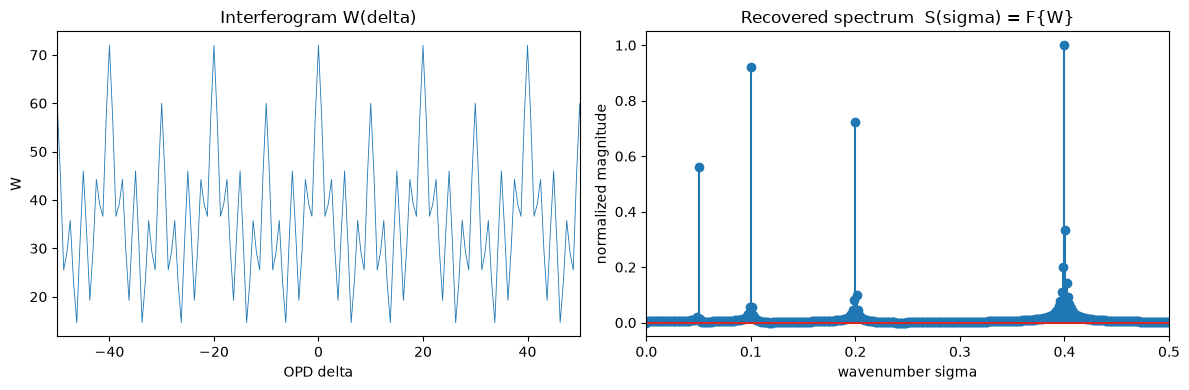

In [2]:
sigmas = np.array([0.05, 0.10, 0.20, 0.40])   # wavenumbers (1 / wavelength)
intensities = np.array([3.0, 5.0, 4.0, 6.0])

# OPD grid: step below the Nyquist limit for the highest line, span sets resolution.
d_delta = 1.0 / (2.0 * 2.0 * sigmas.max())
n_side = int(400.0 / d_delta)
delta = np.arange(-n_side, n_side + 1) * d_delta

W = sum(2.0 * I * (1.0 + np.cos(2.0 * np.pi * s * delta))
        for s, I in zip(sigmas, intensities))

sigma_axis, mag = ftir.recover_spectrum(delta, W)
peaks = np.sort(ftir.find_absorption_bands(sigma_axis, mag / mag.max(), height=0.1))
print("expected sigma :", sigmas)
print("recovered sigma:", np.round(peaks[:4], 4))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(delta, W, lw=0.6)
ax1.set_xlim(-50, 50); ax1.set_title("Interferogram W(delta)")
ax1.set_xlabel("OPD delta"); ax1.set_ylabel("W")
ax2.stem(sigma_axis, mag / mag.max())
ax2.set_xlim(0, 0.5); ax2.set_title("Recovered spectrum  S(sigma) = F{W}")
ax2.set_xlabel("wavenumber sigma"); ax2.set_ylabel("normalized magnitude")
plt.tight_layout(); plt.show()

## 2. Interactive FTIR simulator

Pick an unknown gas and instrument settings, then watch the full FTIR chain. Each numeric control is a **slider + text box** (drag or type a value, clamped to range).

| Control | Meaning |
| --- | --- |
| **gas** | Sample gas drawn from the built-in library (the "unknown" to identify). |
| **concentration** | Scales the absorbance (path length x concentration); deeper bands at higher values. |
| **temperature (K)** | IR source temperature; shifts the broadband envelope (Planck law in wavenumber). |
| **max OPD (cm)** | Largest optical path difference -> spectral resolution $\Delta\sigma = 1/(2\,\delta_\text{max})$. |
| **band shape** | `gaussian` or `lorentzian` absorption line shape. |

Panels: (a) source vs sample single-beam spectra, (b) interferogram $I(\delta)$, (c) recovered transmittance and absorbance with detected band markers.

In [ ]:
SIGMA = ftir.default_wavenumber_grid(400.0, 4000.0, 2048)   # mid-IR grid (cm^-1)


def linked_float(min_val, max_val, step, value, description, text_width="90px"):
    """FloatSlider + BoundedFloatText sharing the same value (slider or keyboard)."""
    slider = FloatSlider(min=min_val, max=max_val, step=step, value=value,
                         description=description, readout=False,
                         layout=widgets.Layout(width="380px"))
    text = BoundedFloatText(min=min_val, max=max_val, step=step, value=value,
                            layout=widgets.Layout(width=text_width))
    link((slider, "value"), (text, "value"))
    return slider, HBox([slider, text])


def run_ftir(gas, concentration, temperature, max_opd_cm, shape):
    source = ftir.source_spectrum(SIGMA, temperature=temperature)
    T_gas = ftir.gas_transmittance(SIGMA, gas, concentration=concentration, shape=shape)
    background = ftir.single_beam_spectrum(SIGMA, source)
    sample = ftir.single_beam_spectrum(SIGMA, source, T_gas)

    d_sigma = ftir.spectral_resolution(max_opd_cm)
    opd = ftir.make_opd_grid(SIGMA.max(), d_sigma)
    ifg = ftir.interferogram(SIGMA, sample, opd)

    sig_rec, mag_sample = ftir.recover_spectrum(opd, ifg)
    _, mag_bg = ftir.recover_spectrum(opd, ftir.interferogram(SIGMA, background, opd))
    band = (sig_rec >= SIGMA.min()) & (sig_rec <= SIGMA.max())
    T_rec = ftir.transmittance_from_beams(mag_sample[band], mag_bg[band])
    A_rec = ftir.absorbance(T_rec)
    sig_band = sig_rec[band]
    bands = ftir.find_absorption_bands(sig_band, A_rec, height=0.05)

    fig, axes = plt.subplots(3, 1, figsize=(11, 9))
    axes[0].plot(SIGMA, background, label="source (background)", color="C1")
    axes[0].plot(SIGMA, sample, label="sample single-beam", color="C0")
    axes[0].set_title(f"(a) Single-beam spectra - {gas}")
    axes[0].set_xlabel("wavenumber (cm^-1)"); axes[0].set_ylabel("intensity")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(opd, ifg, lw=0.5, color="C2")
    axes[1].set_xlim(-0.05, 0.05)
    axes[1].set_title(f"(b) Interferogram I(delta)   (resolution {d_sigma:.1f} cm^-1)")
    axes[1].set_xlabel("OPD delta (cm)"); axes[1].set_ylabel("intensity")
    axes[1].grid(alpha=0.3)

    axes[2].plot(sig_band, T_rec, color="C3", label="transmittance")
    axes[2].plot(sig_band, ftir.absorbance(T_rec) / max(A_rec.max(), 1e-9),
                 color="C4", alpha=0.6, label="absorbance (norm.)")
    for b in bands[:6]:
        axes[2].axvline(b, color="gray", ls=":", alpha=0.7)
        axes[2].text(b, 1.02, f"{b:.0f}", rotation=90, va="bottom", fontsize=8)
    axes[2].set_title("(c) Recovered transmittance / absorbance with detected bands")
    axes[2].set_xlabel("wavenumber (cm^-1)"); axes[2].set_ylabel("value")
    axes[2].set_ylim(0, 1.15); axes[2].legend(loc="lower right"); axes[2].grid(alpha=0.3)
    plt.tight_layout(); plt.show()


gas = Dropdown(options=sorted(ftir.GAS_LIBRARY), value="CO2", description="gas")
shape = Dropdown(options=["gaussian", "lorentzian"], value="gaussian", description="band shape")
concentration, conc_box = linked_float(0.2, 5.0, 0.1, 1.0, "concentration")
temperature, temp_box = linked_float(600, 2000, 50, 1200, "temperature (K)")
max_opd, opd_box = linked_float(0.05, 1.0, 0.05, 0.5, "max OPD (cm)")

controls = VBox([gas, conc_box, temp_box, opd_box, shape])
out = interactive_output(run_ftir, {
    "gas": gas, "concentration": concentration, "temperature": temperature,
    "max_opd_cm": max_opd, "shape": shape,
})
display(VBox([controls, out]))

## 3. Qualitative identification

Because each compound has a unique combination of vibrational bands, its IR spectrum is a fingerprint. We measure an "unknown" through the full FTIR chain (interferogram then FFT recovery), then rank the library gases by **cosine similarity** between the recovered absorbance and each gas's reference signature. The top score is the identified gas.

Set `UNKNOWN` below to a single gas or a mixture (dict of `gas -> concentration`).

Unknown sample: H2O
Detected bands (cm^-1): [1595. 3701.]

Library match ranking (cosine similarity):
  H2O  :  1.000  <== best match
  SO2  :  0.000
  CO2  :  0.000
  N2O  :  0.000
  CH4  :  0.000
  CO   :  0.000

Identified gas: H2O  (score 1.000)


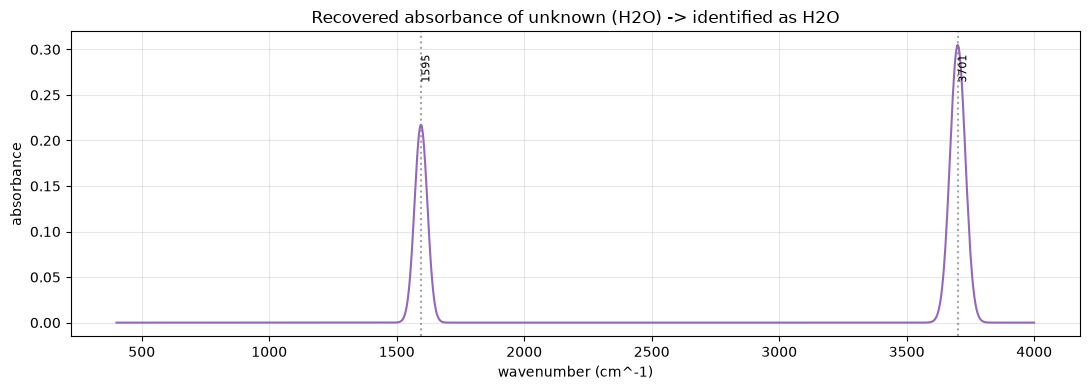

In [6]:
UNKNOWN = "H2O"                 # try "CO", "SO2", or a mixture: {"CO2": 1.0, "CH4": 0.6}

source = ftir.source_spectrum(SIGMA, temperature=1200.0)
if isinstance(UNKNOWN, dict):
    T_unknown = ftir.mixture_transmittance(SIGMA, UNKNOWN)
    label = " + ".join(f"{g}({c})" for g, c in UNKNOWN.items())
else:
    T_unknown = ftir.gas_transmittance(SIGMA, UNKNOWN)
    label = UNKNOWN

background = ftir.single_beam_spectrum(SIGMA, source)
sample = ftir.single_beam_spectrum(SIGMA, source, T_unknown)

opd = ftir.make_opd_grid(SIGMA.max(), ftir.spectral_resolution(0.5))
sig_rec, mag_sample = ftir.recover_spectrum(opd, ftir.interferogram(SIGMA, sample, opd))
_, mag_bg = ftir.recover_spectrum(opd, ftir.interferogram(SIGMA, background, opd))
band = (sig_rec >= SIGMA.min()) & (sig_rec <= SIGMA.max())
A_rec = ftir.absorbance(ftir.transmittance_from_beams(mag_sample[band], mag_bg[band]))
sig_band = sig_rec[band]

ranking = ftir.identify_gas(sig_band, A_rec)
best_gas, best_score = ranking[0]

print(f"Unknown sample: {label}")
print(f"Detected bands (cm^-1): {np.round(np.sort(ftir.find_absorption_bands(sig_band, A_rec, height=0.05))[:6], 0)}")
print("\nLibrary match ranking (cosine similarity):")
for g, s in ranking:
    marker = "  <== best match" if g == best_gas else ""
    print(f"  {g:5s}: {s:6.3f}{marker}")
print(f"\nIdentified gas: {best_gas}  (score {best_score:.3f})")

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(sig_band, A_rec, color="C4")
for b in np.sort(ftir.find_absorption_bands(sig_band, A_rec, height=0.05))[:6]:
    ax.axvline(b, color="gray", ls=":", alpha=0.7)
    ax.text(b, ax.get_ylim()[1] * 0.92, f"{b:.0f}", rotation=90, fontsize=8, va="top")
ax.set_title(f"Recovered absorbance of unknown ({label}) -> identified as {best_gas}")
ax.set_xlabel("wavenumber (cm^-1)"); ax.set_ylabel("absorbance")
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()